In [43]:
#Abertura das Bibliotecas utilizadas
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import netCDF4 as nc
import plotly.express as px
import plotly.graph_objects as go
import cartopy.crs as ccrs # Escolha do sistema de coordenadas
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature
import matplotlib.patches as mpatches # Desenhar geometria em um mapa
import matplotlib.ticker as mticker
import rasterio

# Abertura dos Dados de Temperatura
Abertura dos arquivo raster de Tmin e Tmax e criação de dataArray dos dois

## Tmax - Temperatura Máxima Média Mensal

In [44]:
import rasterio
import numpy as np
'''
#Abre o arquivo de Tmax tif.
tmax_raster_1 = rasterio.open("Dados_tmin_tmax/01-Tmax_01_1985_02_1990.tif").read()
print('01-Tmax_01_1985_02_1990',tmax_raster_1.shape)

#Abre o arquivo de Tmax tif.
tmax_raster_2 = rasterio.open("Dados_tmin_tmax/02-Tmax_03_1990_12_1994.tif").read()
print('02-Tmax_03_1990_12_1994',tmax_raster_2.shape)

#Abre o arquivo de Tmax tif.
tmax_raster_3 = rasterio.open("Dados_tmin_tmax/03-Tmax_01_1995_12_1999.tif").read()
print('03-Tmax_01_1995_12_1999',tmax_raster_3.shape)

#Abre o arquivo de Tmax tif.
tmax_raster_4 = rasterio.open("Dados_tmin_tmax/04-Tmax_01_2000_12_2004.tif").read()
print('04-Tmax_01_2000_12_2004',tmax_raster_4.shape)

#Abre o arquivo de Tmax tif.
tmax_raster_5 = rasterio.open("Dados_tmin_tmax/05-Tmax_01_2005_12_2009.tif").read()
print('05-Tmax_01_2005_12_2009',tmax_raster_5.shape)

#Abre o arquivo de Tmax tif.
tmax_raster_6 = rasterio.open("Dados_tmin_tmax/06-Tmax_01_2010_12_2014.tif").read()
print('06-Tmax_01_2010_12_2014',tmax_raster_6.shape)

#Abre o arquivo de Tmax tif.
tmax_raster_7 = rasterio.open("Dados_tmin_tmax/07-Tmax_01_2015_12_2019.tif").read()
print('07-Tmax_01_2015_12_2019',tmax_raster_7.shape)

#Abre o arquivo de Tmax tif.
tmax_raster_8 = rasterio.open("Dados_tmin_tmax/08-Tmax_01_2020_02_2024.tif").read()
print('08-Tmax_01_2020_02_2024',tmax_raster_8.shape)
'''
#Abertura do Arquivo, se houverem outro colocar 
tmax_raster = rasterio.open("Dados_tmin_tmax/salvatmax.tif").read()
print('Tmax',tmax_raster.shape)

Tmax (12, 750, 551)


# Em caso de vários arquivos .TIF - Une os arquivos em um só para a geração de NetCDF

In [45]:
'''
import numpy as np
# Adicionar a nova camada temporal
tmax_raster = np.concatenate((tmax_raster_1, tmax_raster_2,tmax_raster_3,tmax_raster_4,tmax_raster_5,tmax_raster_6,tmax_raster_7,tmax_raster_8), axis=0)

# Verificar as novas dimensões
print("Dimensões após adicionar camada temporal:", tmax_raster.shape)
'''
# Separa os valores do shape
mesesTmax, latitudeTmax, longitudeTmax = tmax_raster.shape

# Imprime os valores separados
print('Número de dados de tempo:', mesesTmax)
print('Número de latitudes:', latitudeTmax)
print('Número de longitudes:', longitudeTmax)


Número de dados de tempo: 12
Número de latitudes: 750
Número de longitudes: 551


In [46]:
import rasterio
import numpy as np

# Abrir o arquivo .tif
with rasterio.open("Dados_tmin_tmax/salvatmax.tif") as src:
    # Ler os dados da imagem (3D - Tempo, Latitude, Longitude)
    precip_data = src.read()

    # Obter a transformação espacial (informações de georreferenciamento)
    transform = src.transform

    # Obter os limites geográficos do arquivo
    bounds = src.bounds

    # Obter as dimensões da imagem (dimensões lat, lon)
    height = src.height
    width = src.width

    # Obter as coordenadas de latitude e longitude
    # O arquivo tem 3 dimensões (tempo, latitude, longitude), então vamos pegar as latitudes e longitudes
    latitudes_tmax = np.linspace(bounds[3], bounds[1], height)  # De baixo para cima
    longitudes_tmax = np.linspace(bounds[0], bounds[2], width)  # Da esquerda para a direita

# Imprimir informações sobre o arquivo e as coordenadas
print("Informações do arquivo .tif:")
print(f"Transformação: {transform}")
print(f"Limites: {bounds}")
print(f"Dimensões: {precip_data.shape}")

print("Primeiras 5 latitudes:", len(latitudes_tmax))
print("Primeiras 5 longitudes:",len(longitudes_tmax))

# Exibir a coordenada de latitude e longitude correspondentes ao primeiro valor de tempo, latitude e longitude
print("Primeiro valor de precipitação (na posição 0, 0):", precip_data[0, 0, 0])  # Tempo, Latitude, Longitude

Informações do arquivo .tif:
Transformação: | 0.10, 0.00,-85.00|
| 0.00,-0.10, 15.00|
| 0.00, 0.00, 1.00|
Limites: BoundingBox(left=-85.00000000000001, bottom=-60.000000000000014, right=-29.900000000000006, top=15.000000000000004)
Dimensões: (12, 750, 551)
Primeiras 5 latitudes: 750
Primeiras 5 longitudes: 551
Primeiro valor de precipitação (na posição 0, 0): 304.6012174544796


# Limpa os arquivos para não ficar tão pesado

In [47]:
import gc

#del tmax_raster_1, tmax_raster_2, tmax_raster_3, tmax_raster_4, tmax_raster_5, tmax_raster_6, tmax_raster_7, tmax_raster_8
#gc.collect()

## Criação de dados de Tempo

In [48]:
import numpy as np

#Definição da data inicial
data_inicial_tmax=np.datetime64('2024-03', 'M')

#Criação de uma lista com as datas mensais - levando em consideração o número de linha de tempo presentes nos dados
data_Tmax = np.arange(data_inicial_tmax,data_inicial_tmax+mesesTmax, dtype="datetime64[M]")

data_Tmax = np.array(data_Tmax, dtype="datetime64[ns]") 
print("Dados de tempo:",data_Tmax.shape)
data_Tmax

Dados de tempo: (12,)


array(['2024-03-01T00:00:00.000000000', '2024-04-01T00:00:00.000000000',
       '2024-05-01T00:00:00.000000000', '2024-06-01T00:00:00.000000000',
       '2024-07-01T00:00:00.000000000', '2024-08-01T00:00:00.000000000',
       '2024-09-01T00:00:00.000000000', '2024-10-01T00:00:00.000000000',
       '2024-11-01T00:00:00.000000000', '2024-12-01T00:00:00.000000000',
       '2025-01-01T00:00:00.000000000', '2025-02-01T00:00:00.000000000'],
      dtype='datetime64[ns]')

## Criação de DataArray

In [49]:
anos = data_Tmax.astype('datetime64[Y]').astype(int) + 1970
anos
ano = anos[0]
ano

2024

In [50]:
import xarray as xr
# Criação do DataArray

anos = data_Tmax.astype('datetime64[Y]').astype(int) + 1970
ano = anos[0]
tmax = xr.Dataset(
    {
        "tmax": (["time", "lat", "lon"], tmax_raster - 273.15) 
    },
    coords={
        "time": data_Tmax,  # A nova dimensão representa os anos
        "lat": latitudes_tmax,
        "lon": longitudes_tmax
    }
)
    # Adicionando atributos ao dataset
tmax.attrs = {
    'title': 'tmax - Temperatura máxima média mensal',
    'units': '°C',
    'source': 'ERA-5 Land - ECMWF',
    'institution': 'IFUSP',
    'creator': 'Arthur Thomas Luz, Orientadores: Profa. Dra. Luciana Rizzo, Dr. Felipe Silva, Prof. Dr. Luiz Augusto Toledo Machado',
    'year_range': f'{anos.min()} - {anos.max()}',
    'geospatial_bounds': 'Oeste: -85°, Sul: -60°, Leste: -30°, Norte: 15°',
    'spatial_resolution': '0.1° x 0.1°',
    'temporal_resolution': 'Anual',
    'comments': 'Erro baseado na climatologia 1981-2010 comparada a 310 estações do INMET.',
    'history': 'Criado em 05/12/2024 com dados ERA-5 Land da Earth Engine.',
}

# Visualização dos dados
display(tmax)

#Salvando em NetCDF
tmax.to_netcdf(f"Dados_tmin_tmax/tmax_{ano}.nc")

<xarray.Dataset> Size: 40MB
Dimensions:  (time: 12, lat: 750, lon: 551)
Coordinates:
  * time     (time) datetime64[ns] 96B 2024-03-01 2024-04-01 ... 2025-02-01
  * lat      (lat) float64 6kB 15.0 14.9 14.8 14.7 ... -59.7 -59.8 -59.9 -60.0
  * lon      (lon) float64 4kB -85.0 -84.9 -84.8 -84.7 ... -30.1 -30.0 -29.9
Data variables:
    tmax     (time, lat, lon) float64 40MB 31.45 31.41 31.58 ... nan nan nan
Attributes:
    title:                tmax - Temperatura máxima média mensal
    units:                °C
    source:               ERA-5 Land - ECMWF
    institution:          IFUSP
    creator:              Arthur Thomas Luz, Orientadores: Profa. Dra. Lucian...
    year_range:           2024 - 2025
    geospatial_bounds:    Oeste: -85°, Sul: -60°, Leste: -30°, Norte: 15°
    spatial_resolution:   0.1° x 0.1°
    temporal_resolution:  Anual
    comments:             Erro baseado na climatologia 1981-2010 comparada a ...
    history:              Criado em 05/12/2024 com dados ERA-5 Land da Earth ...

# Visualização Mapa

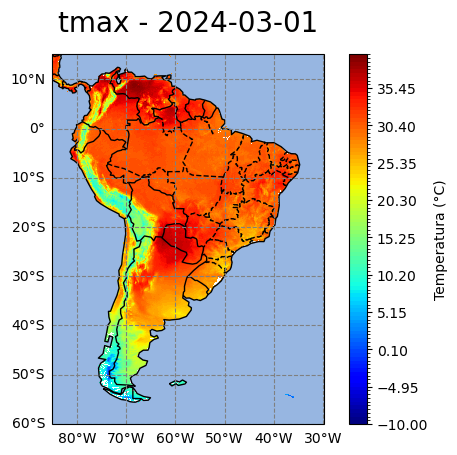

In [61]:
#Criando Mapa de Temperatura Anual média
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs # Escolha do sistema de coordenadas
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import xarray as xr
import cartopy.feature as cfeature

#***********************************************************************************************
Dado = tmax
var = 'tmax'
data ='2024-03-01'
#***********************************************************************************************

# Configurar o plot
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
               
Base = Dado[var].sel(time=data) 
# Plotar a média da temperatura
Base.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='jet',levels=np.linspace(-10, 40, 100), cbar_kwargs={'label': 'Temperatura (°C)'})
#levels=np.linspace(10, 30, 21) é utilizado para definir que a colorBar vai de 10° C até 30°, tendo 21 ponto 


#Adicionando o contorno dos continentes, países e estados do Brasil
#Adicionando o contorno dos continentes
ax.add_feature(cfeature.COASTLINE)

#Adicionando os limites dos países
ax.add_feature(cfeature.BORDERS)

#Adicionando o oceano
ax.add_feature(cfeature.OCEAN)

#Adicionando os limites estaduais
states = cfeature.NaturalEarthFeature(category='cultural',
                                      name='admin_1_states_provinces_lines',
                                      scale='50m',
                                      facecolor='none')
ax.add_feature(states, edgecolor='k', linestyle='--')

#Adicionando título a figura 
ax.set_title(f'{var} - {data}', fontsize=20, y=1.04)

#Adicionando as linhas de grade
g1 = ax.gridlines(crs=ccrs.PlateCarree(), linestyle='--', color='gray', draw_labels=True)

#Formatando os labels como latitude e longitude
g1.yformatter = LATITUDE_FORMATTER
g1.xformatter = LONGITUDE_FORMATTER

#agora irei tirar as grades  superior e direita
# Remove as linhas de grade à direita
g1.ylabels_right = False  # Remove labels do eixo y à direita
g1.right_labels = False  # Remove a linha de grade à direita
g1.y_inline = False  # Evita que as linhas de grade internas sejam desenhadas

# Remove as linhas de grade no topo (se necessário)
g1.xlabels_top = False  # Remove labels do eixo x no topo

# Remove as linhas de grade no topo (se necessário)
g1.xlabels_top = False  # Remove labels do eixo x no topo
g1.top_labels = False  # Remove a linha de grade no topo


## Tmin - Temperatura Mínima Média Mensal

In [51]:
import rasterio
import numpy as np
'''
#Abre o arquivo de Tmax tif.
tmax_raster_1 = rasterio.open("Dados_tmin_tmax/01-Tmax_01_1985_02_1990.tif").read()
print('01-Tmax_01_1985_02_1990',tmax_raster_1.shape)

#Abre o arquivo de Tmax tif.
tmax_raster_2 = rasterio.open("Dados_tmin_tmax/02-Tmax_03_1990_12_1994.tif").read()
print('02-Tmax_03_1990_12_1994',tmax_raster_2.shape)

#Abre o arquivo de Tmax tif.
tmax_raster_3 = rasterio.open("Dados_tmin_tmax/03-Tmax_01_1995_12_1999.tif").read()
print('03-Tmax_01_1995_12_1999',tmax_raster_3.shape)

#Abre o arquivo de Tmax tif.
tmax_raster_4 = rasterio.open("Dados_tmin_tmax/04-Tmax_01_2000_12_2004.tif").read()
print('04-Tmax_01_2000_12_2004',tmax_raster_4.shape)

#Abre o arquivo de Tmax tif.
tmax_raster_5 = rasterio.open("Dados_tmin_tmax/05-Tmax_01_2005_12_2009.tif").read()
print('05-Tmax_01_2005_12_2009',tmax_raster_5.shape)

#Abre o arquivo de Tmax tif.
tmax_raster_6 = rasterio.open("Dados_tmin_tmax/06-Tmax_01_2010_12_2014.tif").read()
print('06-Tmax_01_2010_12_2014',tmax_raster_6.shape)

#Abre o arquivo de Tmax tif.
tmax_raster_7 = rasterio.open("Dados_tmin_tmax/07-Tmax_01_2015_12_2019.tif").read()
print('07-Tmax_01_2015_12_2019',tmax_raster_7.shape)

#Abre o arquivo de Tmax tif.
tmax_raster_8 = rasterio.open("Dados_tmin_tmax/08-Tmax_01_2020_02_2024.tif").read()
print('08-Tmax_01_2020_02_2024',tmax_raster_8.shape)
'''
#Abertura do Arquivo, se houverem outro colocar 
tmin_raster = rasterio.open("Dados_tmin_tmax/salvatmin.tif").read()
print('Tmax',tmin_raster.shape)

Tmax (12, 750, 551)


# Em caso de vários arquivos .TIF - Une os arquivos em um só para a geração de NetCDF

In [52]:
'''
import numpy as np
# Adicionar a nova camada temporal
tmax_raster = np.concatenate((tmax_raster_1, tmax_raster_2,tmax_raster_3,tmax_raster_4,tmax_raster_5,tmax_raster_6,tmax_raster_7,tmax_raster_8), axis=0)

# Verificar as novas dimensões
print("Dimensões após adicionar camada temporal:", tmax_raster.shape)
'''
# Separa os valores do shape
mesesTmin, latitudeTmin, longitudeTmin = tmin_raster.shape

# Imprime os valores separados
print('Número de dados de tempo:', mesesTmin)
print('Número de latitudes:', latitudeTmin)
print('Número de longitudes:', longitudeTmin)

Número de dados de tempo: 12
Número de latitudes: 750
Número de longitudes: 551


In [53]:
import rasterio
import numpy as np

# Abrir o arquivo .tif
with rasterio.open("Dados_tmin_tmax/salvatmin.tif") as src:
    # Ler os dados da imagem (3D - Tempo, Latitude, Longitude)
    precip_data = src.read()

    # Obter a transformação espacial (informações de georreferenciamento)
    transform = src.transform

    # Obter os limites geográficos do arquivo
    bounds = src.bounds

    # Obter as dimensões da imagem (dimensões lat, lon)
    height = src.height
    width = src.width

    # Obter as coordenadas de latitude e longitude
    # O arquivo tem 3 dimensões (tempo, latitude, longitude), então vamos pegar as latitudes e longitudes
    latitudes_tmin = np.linspace(bounds[3], bounds[1], height)  # De baixo para cima
    longitudes_tmin = np.linspace(bounds[0], bounds[2], width)  # Da esquerda para a direita

# Imprimir informações sobre o arquivo e as coordenadas
print("Informações do arquivo .tif:")
print(f"Transformação: {transform}")
print(f"Limites: {bounds}")
print(f"Dimensões: {precip_data.shape}")

print("Primeiras 5 latitudes:", len(latitudes_tmin))
print("Primeiras 5 longitudes:",len(longitudes_tmin))

# Exibir a coordenada de latitude e longitude correspondentes ao primeiro valor de tempo, latitude e longitude
print("Primeiro valor de precipitação (na posição 0, 0):", precip_data[0, 0, 0])  # Tempo, Latitude, Longitude

Informações do arquivo .tif:
Transformação: | 0.10, 0.00,-85.00|
| 0.00,-0.10, 15.00|
| 0.00, 0.00, 1.00|
Limites: BoundingBox(left=-85.00000000000001, bottom=-60.000000000000014, right=-29.900000000000006, top=15.000000000000004)
Dimensões: (12, 750, 551)
Primeiras 5 latitudes: 750
Primeiras 5 longitudes: 551
Primeiro valor de precipitação (na posição 0, 0): 295.3275727302797


## Criação de dados de Tempo

In [54]:
import numpy as np

#Definição da data inicial
data_inicial_tmin=np.datetime64('2024-03', 'M')

#Criação de uma lista com as datas mensais - levando em consideração o número de linha de tempo presentes nos dados
data_Tmin = np.arange(data_inicial_tmin,data_inicial_tmin+mesesTmin, dtype="datetime64[M]")

data_Tmin = np.array(data_Tmin, dtype="datetime64[ns]") 
print("Dados de tempo:",data_Tmin.shape)
data_Tmin

Dados de tempo: (12,)


array(['2024-03-01T00:00:00.000000000', '2024-04-01T00:00:00.000000000',
       '2024-05-01T00:00:00.000000000', '2024-06-01T00:00:00.000000000',
       '2024-07-01T00:00:00.000000000', '2024-08-01T00:00:00.000000000',
       '2024-09-01T00:00:00.000000000', '2024-10-01T00:00:00.000000000',
       '2024-11-01T00:00:00.000000000', '2024-12-01T00:00:00.000000000',
       '2025-01-01T00:00:00.000000000', '2025-02-01T00:00:00.000000000'],
      dtype='datetime64[ns]')

## Criação de DataArray

In [55]:
import xarray as xr
# Criação do DataArray

anos = data_Tmin.astype('datetime64[Y]').astype(int) + 1970
ano = anos[0]
tmin = xr.Dataset(
    {
        "tmin": (["time", "lat", "lon"], tmin_raster - 273.15) 
    },
    coords={
        "time": data_Tmin,  # A nova dimensão representa os anos
        "lat": latitudes_tmin,
        "lon": longitudes_tmin
    }
)
    # Adicionando atributos ao dataset
tmin.attrs = {
    'title': 'tmin - Temperatura máxima média mensal',
    'units': '°C',
    'source': 'ERA-5 Land - ECMWF',
    'institution': 'IFUSP',
    'creator': 'Arthur Thomas Luz, Orientadores: Profa. Dra. Luciana Rizzo, Dr. Felipe Silva, Prof. Dr. Luiz Augusto Toledo Machado',
    'year_range': f'{anos.min()} - {anos.max()}',
    'geospatial_bounds': 'Oeste: -85°, Sul: -60°, Leste: -30°, Norte: 15°',
    'spatial_resolution': '0.1° x 0.1°',
    'temporal_resolution': 'Anual',
    'comments': 'Erro baseado na climatologia 1981-2010 comparada a 310 estações do INMET.',
    'history': 'Criado em 05/12/2024 com dados ERA-5 Land da Earth Engine.',
}

# Visualização dos dados
display(tmin)

#Salvando em NetCDF
tmin.to_netcdf(f"Dados_tmin_tmax/tmin_{ano}.nc")

<xarray.Dataset> Size: 40MB
Dimensions:  (time: 12, lat: 750, lon: 551)
Coordinates:
  * time     (time) datetime64[ns] 96B 2024-03-01 2024-04-01 ... 2025-02-01
  * lat      (lat) float64 6kB 15.0 14.9 14.8 14.7 ... -59.7 -59.8 -59.9 -60.0
  * lon      (lon) float64 4kB -85.0 -84.9 -84.8 -84.7 ... -30.1 -30.0 -29.9
Data variables:
    tmin     (time, lat, lon) float64 40MB 22.18 22.22 22.67 ... nan nan nan
Attributes:
    title:                tmin - Temperatura máxima média mensal
    units:                °C
    source:               ERA-5 Land - ECMWF
    institution:          IFUSP
    creator:              Arthur Thomas Luz, Orientadores: Profa. Dra. Lucian...
    year_range:           2024 - 2025
    geospatial_bounds:    Oeste: -85°, Sul: -60°, Leste: -30°, Norte: 15°
    spatial_resolution:   0.1° x 0.1°
    temporal_resolution:  Anual
    comments:             Erro baseado na climatologia 1981-2010 comparada a ...
    history:              Criado em 05/12/2024 com dados ERA-5 Land da Earth ...

# Visualização Mapa

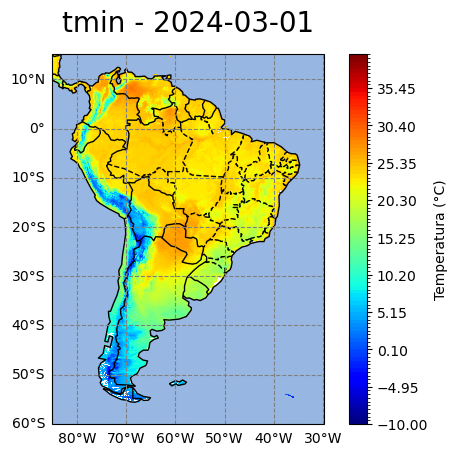

In [62]:
#Criando Mapa de Temperatura Anual média
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs # Escolha do sistema de coordenadas
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import xarray as xr
import cartopy.feature as cfeature

#***********************************************************************************************
Dado = tmin
var = 'tmin'
data ='2024-03-01'
#***********************************************************************************************

# Configurar o plot
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
               
Base = Dado[var].sel(time=data) 
# Plotar a média da temperatura
Base.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='jet',levels=np.linspace(-10, 40, 100), cbar_kwargs={'label': 'Temperatura (°C)'})
#levels=np.linspace(10, 30, 21) é utilizado para definir que a colorBar vai de 10° C até 30°, tendo 21 ponto 


#Adicionando o contorno dos continentes, países e estados do Brasil
#Adicionando o contorno dos continentes
ax.add_feature(cfeature.COASTLINE)

#Adicionando os limites dos países
ax.add_feature(cfeature.BORDERS)

#Adicionando o oceano
ax.add_feature(cfeature.OCEAN)

#Adicionando os limites estaduais
states = cfeature.NaturalEarthFeature(category='cultural',
                                      name='admin_1_states_provinces_lines',
                                      scale='50m',
                                      facecolor='none')
ax.add_feature(states, edgecolor='k', linestyle='--')

#Adicionando título a figura 
ax.set_title(f'{var} - {data}', fontsize=20, y=1.04)

#Adicionando as linhas de grade
g1 = ax.gridlines(crs=ccrs.PlateCarree(), linestyle='--', color='gray', draw_labels=True)

#Formatando os labels como latitude e longitude
g1.yformatter = LATITUDE_FORMATTER
g1.xformatter = LONGITUDE_FORMATTER

#agora irei tirar as grades  superior e direita
# Remove as linhas de grade à direita
g1.ylabels_right = False  # Remove labels do eixo y à direita
g1.right_labels = False  # Remove a linha de grade à direita
g1.y_inline = False  # Evita que as linhas de grade internas sejam desenhadas

# Remove as linhas de grade no topo (se necessário)
g1.xlabels_top = False  # Remove labels do eixo x no topo

# Remove as linhas de grade no topo (se necessário)
g1.xlabels_top = False  # Remove labels do eixo x no topo
g1.top_labels = False  # Remove a linha de grade no topo
